In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
from brain_image.model.eeg_alignment import EEGAlignmentModel

cp_path = Path("experiments/encoders/251025024843tpfgkr-slurmarr14438732_7/version_0/checkpoints/train_eeg-epoch_497-val-loss_1.0811.ckpt")
model = EEGAlignmentModel.load_from_checkpoint(cp_path, compile=False)
model.eval()

EEGAlignmentModel(
  (loss): CrossEntropyLoss()
  (prior): SimpleDiffusionPrior(
    (time_proj): Timesteps()
    (input_proj): Sequential(
      (0): Linear(in_features=1024, out_features=1024, bias=True)
      (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (2): SiLU()
    )
    (time_encoders): ModuleList(
      (0): TimestepEmbedding(
        (linear_1): Linear(in_features=512, out_features=1024, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=1024, out_features=1024, bias=True)
      )
      (1): TimestepEmbedding(
        (linear_1): Linear(in_features=512, out_features=512, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=512, out_features=512, bias=True)
      )
      (2): TimestepEmbedding(
        (linear_1): Linear(in_features=512, out_features=256, bias=True)
        (act): SiLU()
        (linear_2): Linear(in_features=256, out_features=256, bias=True)
      )
      (3): TimestepEmbedding(
        (linear_1): 

In [5]:
dl = model.test_dataloader()
ex_batch = next(iter(dl))

In [6]:
import torch
device, dtype = model._get_device_dtype()
with torch.no_grad():
    eeg_latent, eeg_latent_normed = model.get_eeg_latent(ex_batch, device, dtype)



In [ ]:
prior_pred = model.get_all_prior_preds(eeg_latent_normed)

Prior sampling: 100%|██████████| 200/200 [00:00<00:00, 457.17it/s]


In [14]:
# Dreamsim
from dreamsim import dreamsim

dreamsim_loss, _ = dreamsim(pretrained=True, dreamsim_type="synclr_vitb16")
dreamsim_loss.eval()



Using cached ./models


/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PeftModel(
  (base_model): LoraModel(
    (model): PerceptualModel(
      (extractor_list): ModuleList(
        (0): ViTExtractor(
          (model): VisionTransformer(
            (patch_embed): PatchEmbed(
              (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
            )
            (pos_drop): Dropout(p=0.0, inplace=False)
            (blocks): ModuleList(
              (0-11): 12 x Block(
                (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
                (attn): Attention(
                  (qkv): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=2304, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Identity()
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=768, out_features=16, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): L

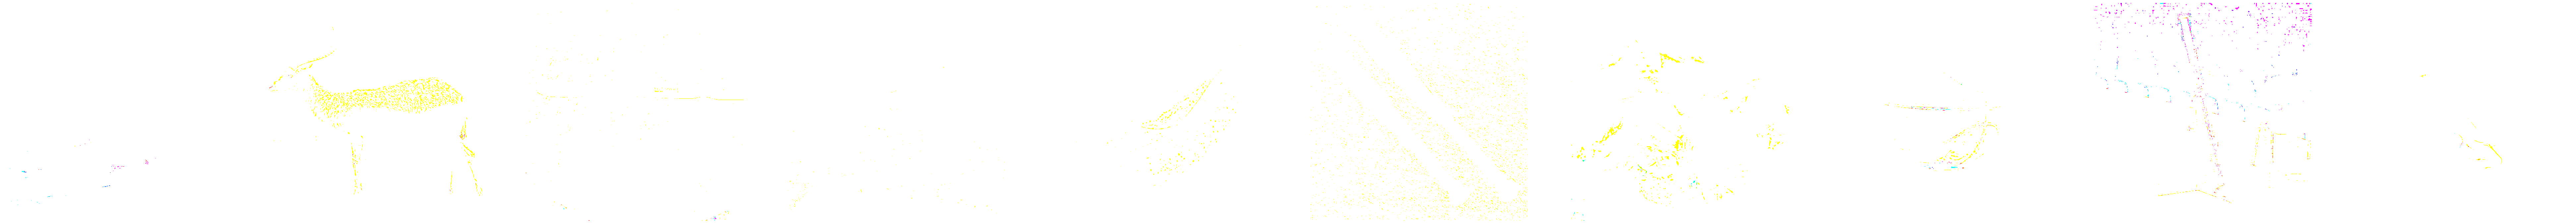

In [16]:
from brain_image.data import batch_load_images
from brain_image.utils import show_image


img_paths = ex_batch["img_path"]
gts = batch_load_images(img_paths)
show_image(gts[:10])

In [17]:
import torchvision.transforms.v2 as tv2
resize_pipe = tv2.Compose([
    tv2.Resize(425, tv2.InterpolationMode.BILINEAR),
    tv2.ToDtype(torch.float, scale=True),
])

In [19]:
preds_rz = resize_pipe(prior_pred)
preds_rz[:10]

ValueError: not enough values to unpack (expected 3, got 2)